# Установка зависимостей

In [1]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop
from scipy.signal import savgol_filter

# Загрузка данных

In [5]:
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

print("Размер обучающей выборки:", train_data.shape)
print("Размер тестовой выборки:", test_data.shape)
print("Первые 5 целевых значений (тыс. $):", test_targets[:5])

Размер обучающей выборки: (404, 13)
Размер тестовой выборки: (102, 13)
Первые 5 целевых значений (тыс. $): [ 7.2 18.8 19.  27.  22.2]


# Предобработка данных


In [7]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std

test_data -= mean
test_data /= std

# Построение модели


In [8]:
def build_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(train_data.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mse', metrics=['mae'])
    return model

# Функция K-fold кросс-валидации

In [17]:
def kfold_cross_validation(K, epochs, verbose=0):
    """
    Выполняет K-fold кросс-валидацию и возвращает список объектов history для каждого фолда.
    """
    num_val_samples = len(train_data) // K
    histories = []

    for i in range(K):
        print(f'Фолд №{i+1}/{K}')
        # Валидационный блок
        val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
        val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

        # Обучающие блоки (все остальные)
        partial_train_data = np.concatenate(
            [train_data[:i * num_val_samples],
             train_data[(i + 1) * num_val_samples:]],
            axis=0
        )
        partial_train_targets = np.concatenate(
            [train_targets[:i * num_val_samples],
             train_targets[(i + 1) * num_val_samples:]],
            axis=0
        )

        model = build_model()
        history = model.fit(
            partial_train_data, partial_train_targets,
            validation_data=(val_data, val_targets),
            epochs=epochs, batch_size=1, verbose=verbose
        )
        histories.append(history)

    return histories

# Определение оптимального числа эпох (точка переобучения)

In [22]:
K = 4
epochs_to_test = 100
print(f"K-fold кросс-валидация с K={K} для анализа числа эпох")
histories = kfold_cross_validation(K, epochs_to_test, verbose=0)


--- K-fold кросс-валидация с K=4 для анализа числа эпох ---
Фолд №1/4
Фолд №2/4
Фолд №3/4
Фолд №4/4


In [54]:
def plot_kfold_metric(histories, metric_name='val_mae', title='Динамика метрики', smooth_window=0, start_epoch=0, optimum=False):
    """
    Строит графики указанной метрики для каждого фолда и усреднённую кривую,
    начиная с эпохи start_epoch+1 (если start_epoch > 0).

    Параметры:
    - histories: список объектов history от K-fold
    - metric_name: название метрики ('loss', 'mae', 'val_loss', 'val_mae')
    - title: заголовок графика
    - smooth_window: размер окна для сглаживания 0 - не применять сглаживание
    - start_epoch: с какой эпохи начинать отображение (0 – все эпохи)
    - optimum: показывать ли автоматически определенное оптимальное число эпох
    """
    plt.figure(figsize=(10, 6))

    curves = [h.history[metric_name] for h in histories]
    epochs = len(curves[0])

    if start_epoch > 0:
        x_range = range(start_epoch + 1, epochs + 1)
        curves_cut = [c[start_epoch:] for c in curves]
    else:
        x_range = range(1, epochs + 1)
        curves_cut = curves

    for i, curve in enumerate(curves_cut):
        plt.plot(x_range, curve, alpha=0.3, linewidth=1, label=f'Фолд {i+1}')

    avg_curve = np.mean(curves_cut, axis=0)
    if smooth_window != 0:
      avg_curve = savgol_filter(avg_curve, window_length=smooth_window, polyorder=2)

    plt.plot(x_range, avg_curve, color='red', linewidth=2, label='Среднее по фолдам')

    if optimum:
      min_idx = np.argmin(avg_curve)
      optimal_epochs = start_epoch + min_idx + 1

      plt.axvline(x=optimal_epochs, color='green', linestyle='--', linewidth=2,
                  label=f'Оптимум: {optimal_epochs} эпох')

    plt.xlabel('Эпохи')
    plt.ylabel(metric_name)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return np.mean(curves, axis=0)

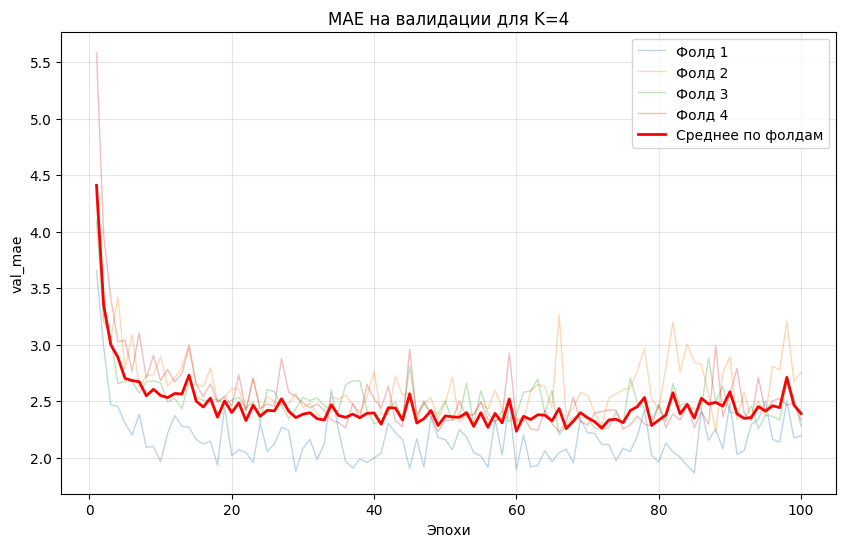

In [55]:
avg_val_mae = plot_kfold_metric(histories, metric_name='val_mae',
                                 title=f'MAE на валидации для K={K}')

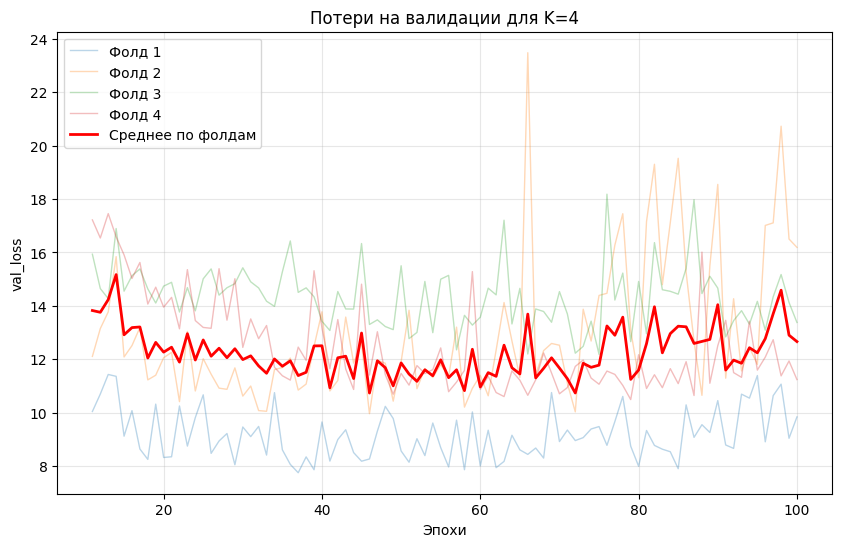

In [59]:
avg_val_loss = plot_kfold_metric(histories, metric_name='val_loss',
                                  title=f'Потери на валидации для K={K}', start_epoch=10)

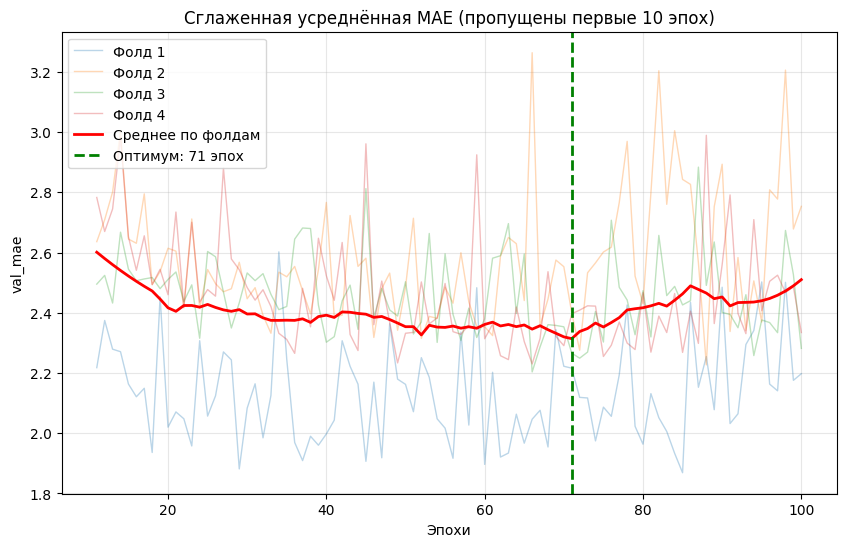

In [53]:
avg_val_mae_avg = plot_kfold_metric(histories, metric_name='val_mae',
                  title=f'Сглаженная усреднённая MAE (пропущены первые 10 эпох)',
                  smooth_window=15, start_epoch=10, optimum=True)

# Исследование влияния параметра K в K-fold проверке

In [64]:
K_values = [2, 3, 4, 5, 6]
optimal_epochs = 71
results = {}
all_histories_by_K = {}
for k in K_values:
    print(f"Вычисление для K={k}...")
    histories_k = kfold_cross_validation(k, optimal_epochs, verbose=0)
    all_histories_by_K[k] = histories_k
    final_maes = [h.history['val_mae'][-1] for h in histories_k]
    avg_mae = np.mean(final_maes)
    results[k] = avg_mae
    print(f"\tСредняя MAE при K={k}: {avg_mae:.4f}")

Вычисление для K=2...
Фолд №1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Фолд №2/2
	Средняя MAE при K=2: 2.5625
Вычисление для K=3...
Фолд №1/3
Фолд №2/3
Фолд №3/3
	Средняя MAE при K=3: 2.4178
Вычисление для K=4...
Фолд №1/4
Фолд №2/4
Фолд №3/4
Фолд №4/4
	Средняя MAE при K=4: 2.4697
Вычисление для K=5...
Фолд №1/5
Фолд №2/5
Фолд №3/5
Фолд №4/5
Фолд №5/5
	Средняя MAE при K=5: 2.3312
Вычисление для K=6...
Фолд №1/6
Фолд №2/6
Фолд №3/6
Фолд №4/6
Фолд №5/6
Фолд №6/6
	Средняя MAE при K=6: 2.4157


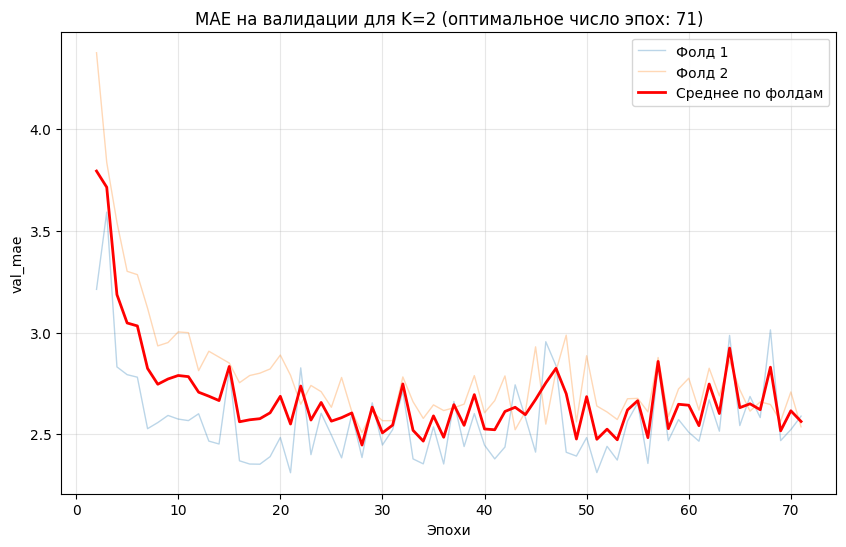

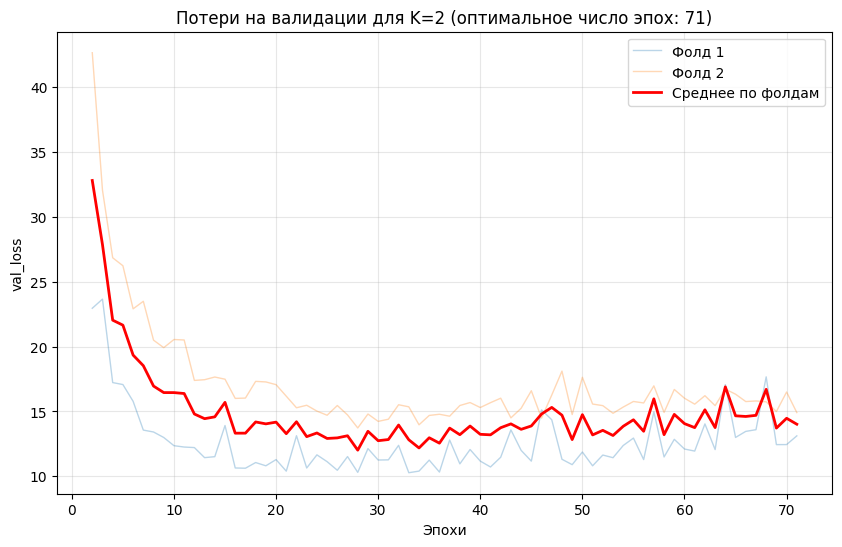

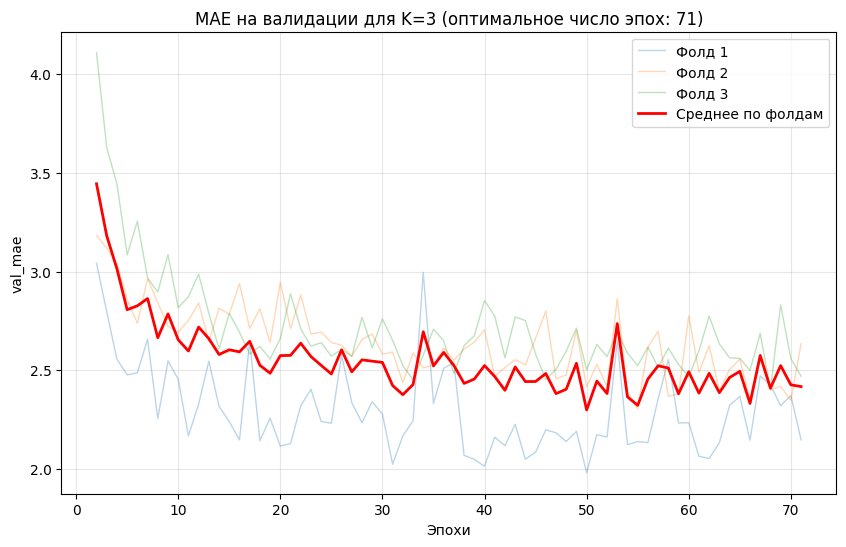

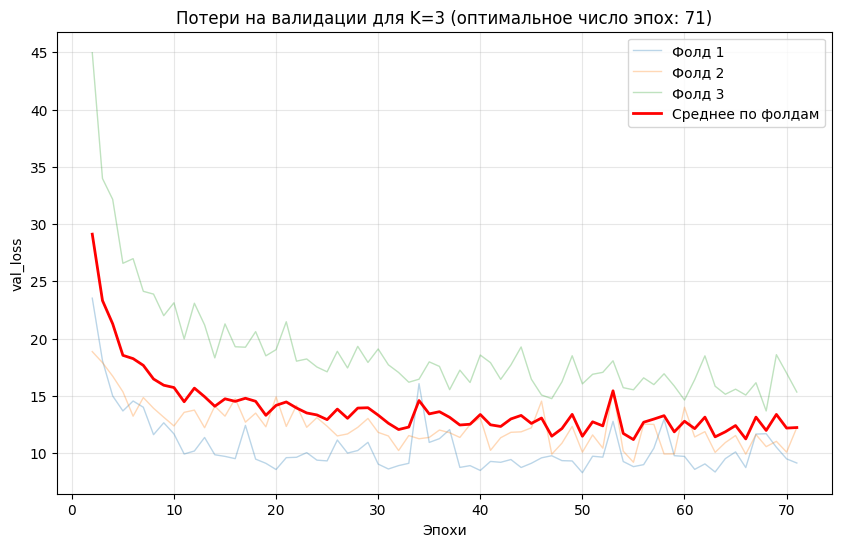

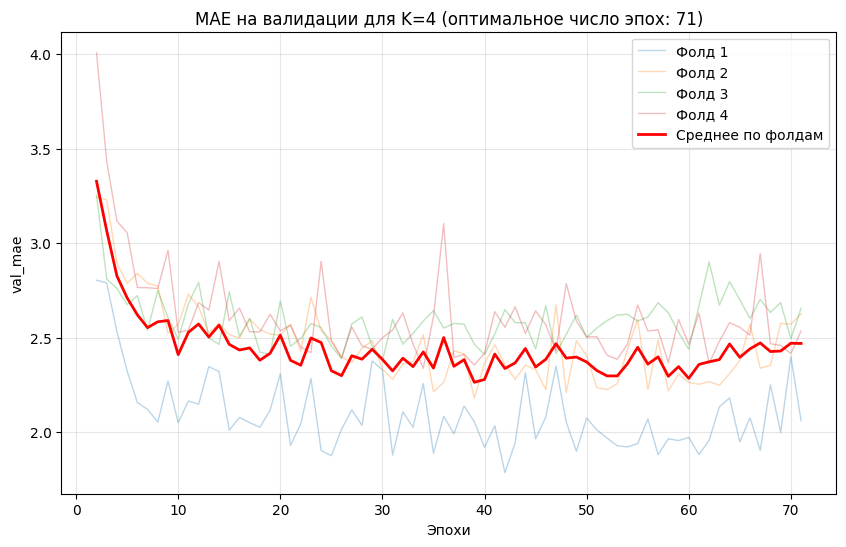

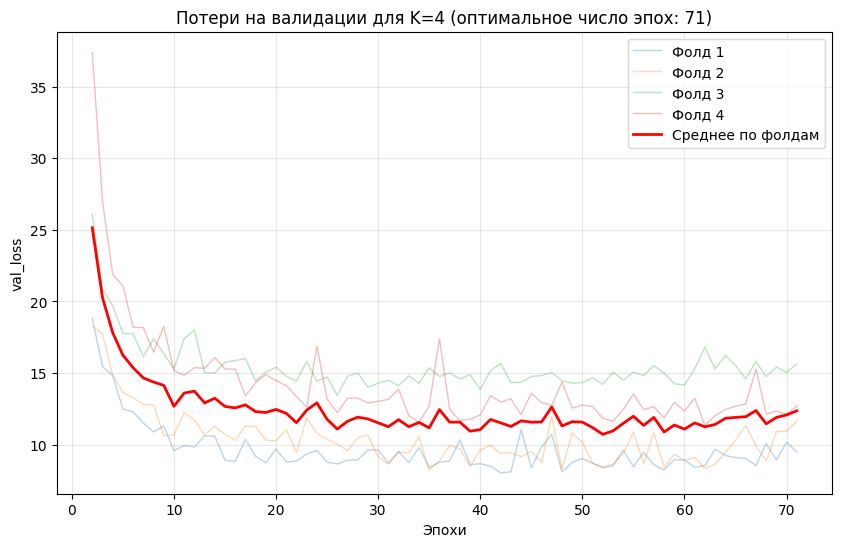

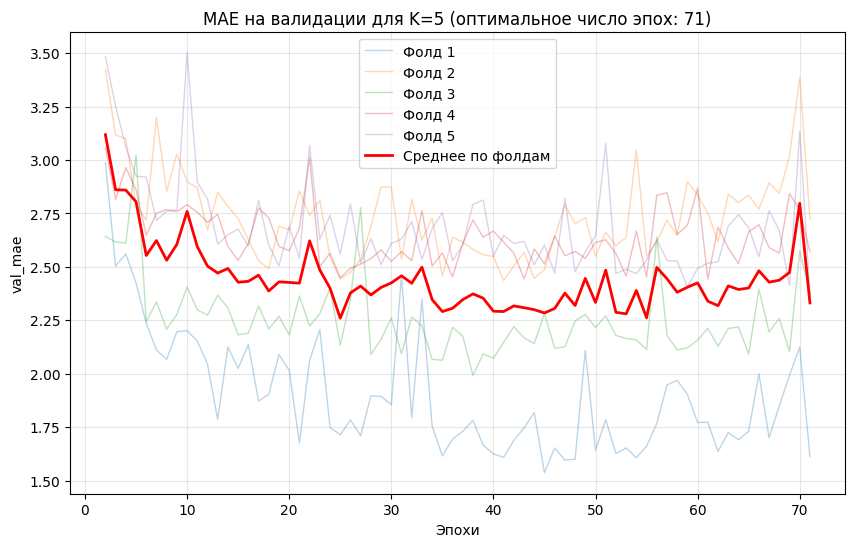

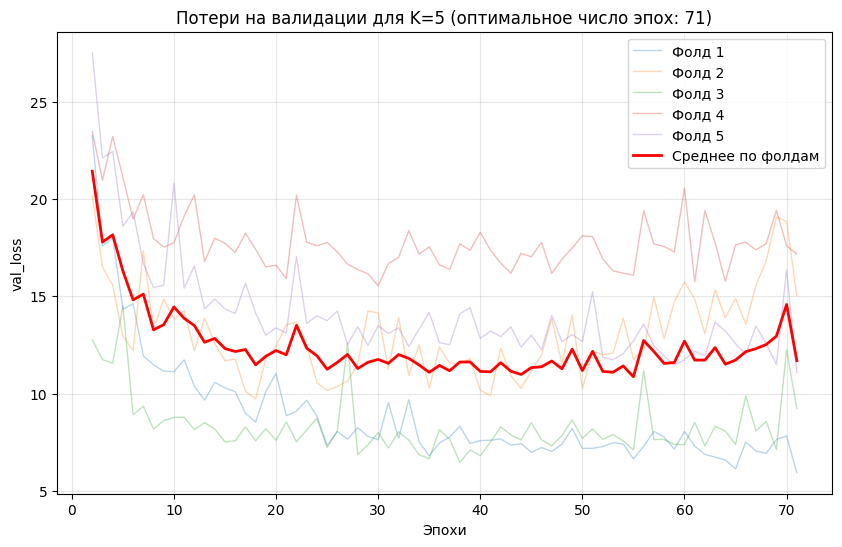

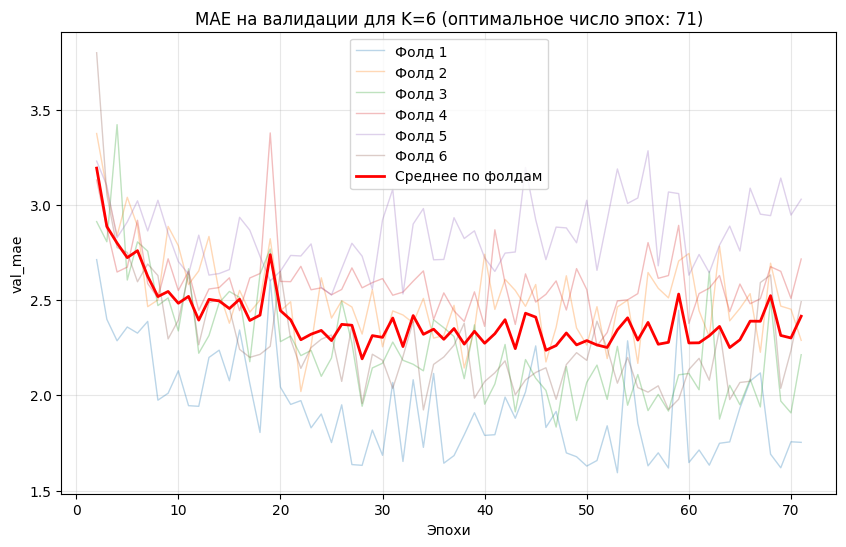

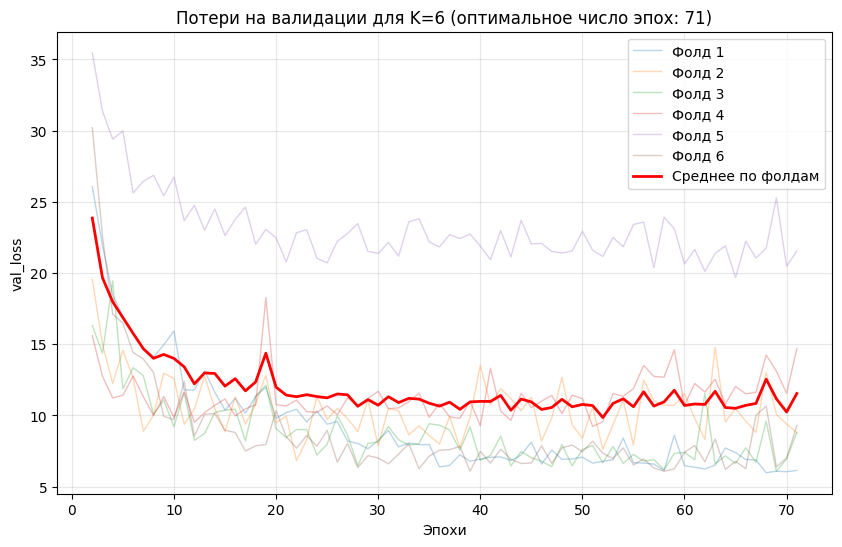

In [67]:
for k, histories_k in all_histories_by_K.items():
  plot_kfold_metric(histories_k, metric_name='val_mae',
                      title=f'MAE на валидации для K={k} (оптимальное число эпох: {optimal_epochs})', start_epoch=1)
  plot_kfold_metric(histories_k, metric_name='val_loss',
                      title=f'Потери на валидации для K={k} (оптимальное число эпох: {optimal_epochs})', start_epoch=1)

In [71]:
def plot_k_comparison(results, title='Сравнение средней MAE при разных K'):
    """Столбчатая диаграмма для сравнения результатов K-fold при разных K."""
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), results.values(), color='skyblue')
    plt.xlabel('K')
    plt.ylabel('Средняя MAE')
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

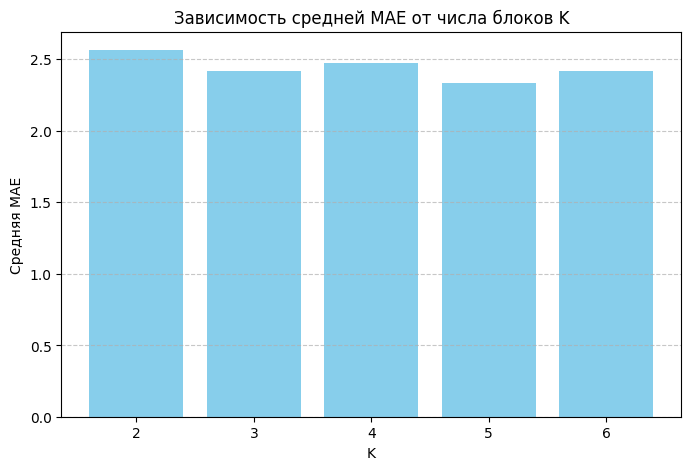

In [72]:
plot_k_comparison(results, title='Зависимость средней MAE от числа блоков K')

# Финальное обучение на всех обучающих данных и оценка на тесте

In [74]:
optimal_epochs = 71
final_model = build_model()
final_model.fit(train_data, train_targets,
                epochs=optimal_epochs, batch_size=1, verbose=0)

test_loss, test_mae = final_model.evaluate(test_data, test_targets, verbose=0)
print(f"Итоговая MAE на тестовой выборке: {test_mae:.4f}")
print(f"Это соответствует средней ошибке {test_mae*1000:.0f}")

Итоговая MAE на тестовой выборке: 2.4694
Это соответствует средней ошибке 2469
